<a href="https://colab.research.google.com/github/ruyoliv/DataCom/blob/main/LineCodes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Códigos de linha

### Os códigos de linha são necessários na transmissão digital para converter dados binários brutos (0s e 1s) em sinais físicos (pulsos de tensão ou luz) adequados para um meio de transmissão específico. Eles permitem funções essenciais como a sincronização do receptor, a eliminação da componente DC, a detecção de erros e a eficiência de largura de banda, garantindo uma transferência de dados confiável.

LINE CODING SCHEMES VISUALIZATION

Enter a binary sequence (default: 1 0 1 1 0 0 1 0):
Binary bits (space-separated): 1 1 0 1 1 0 1 1

Using bits: [1, 1, 0, 1, 1, 0, 1, 1]


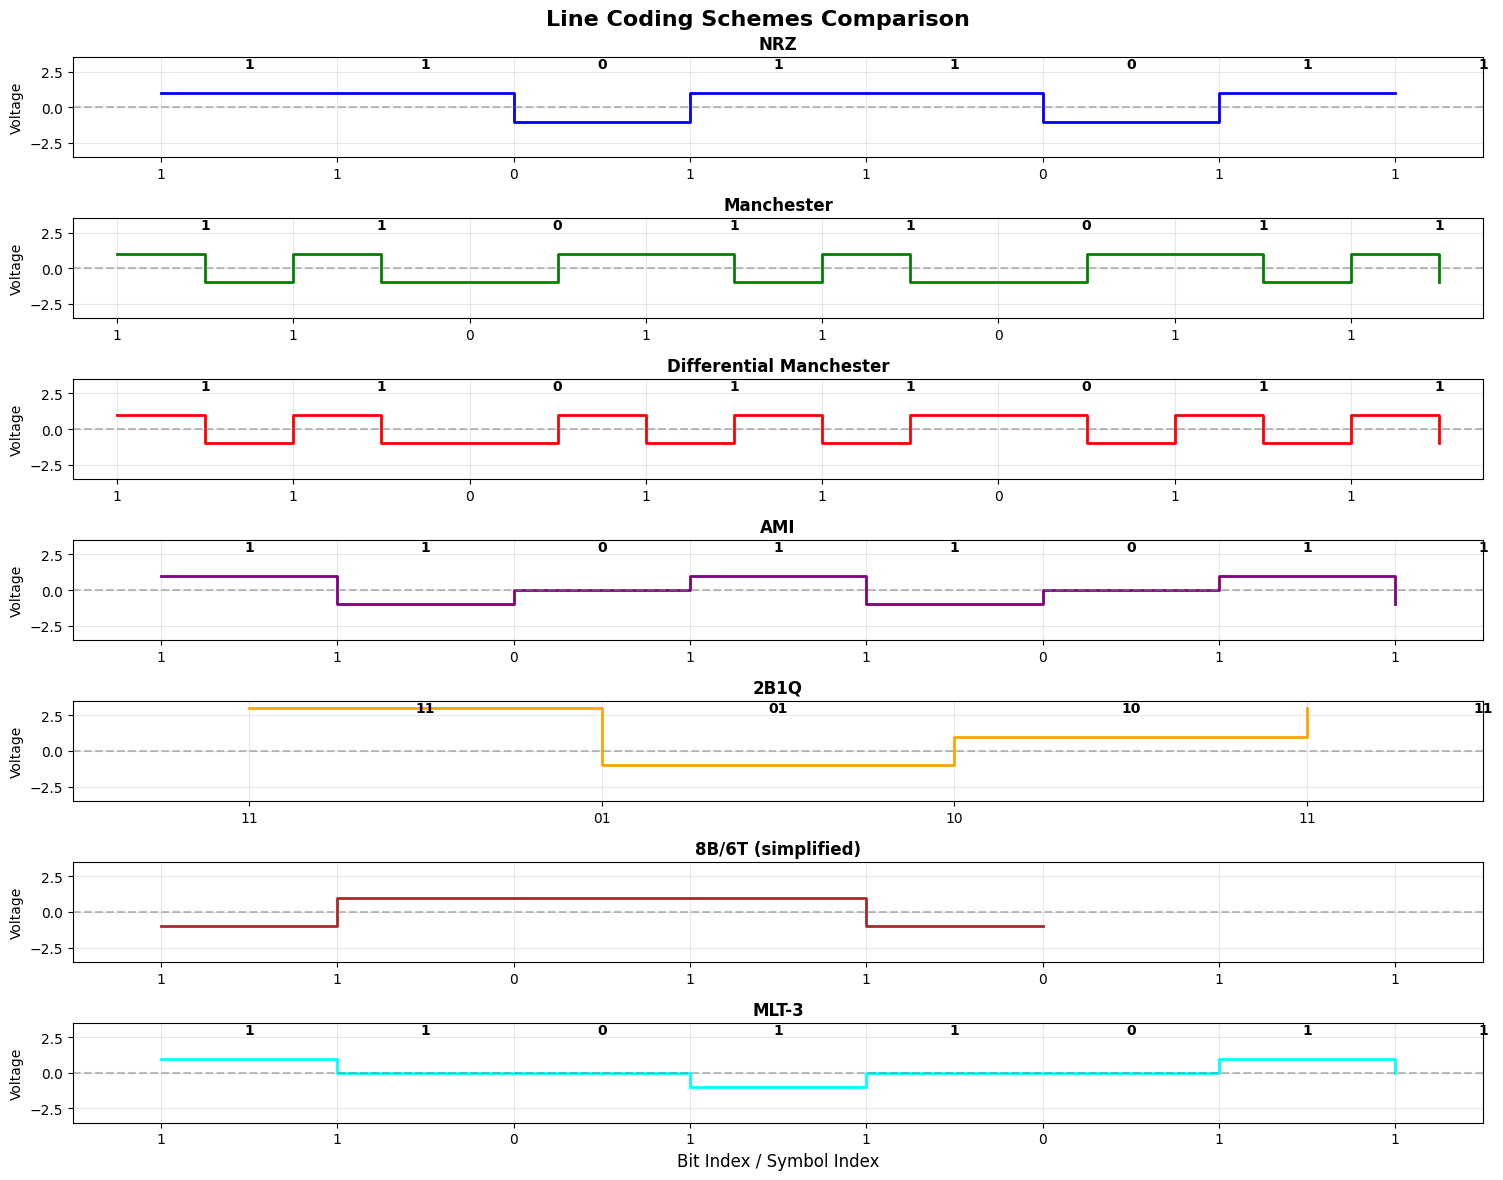

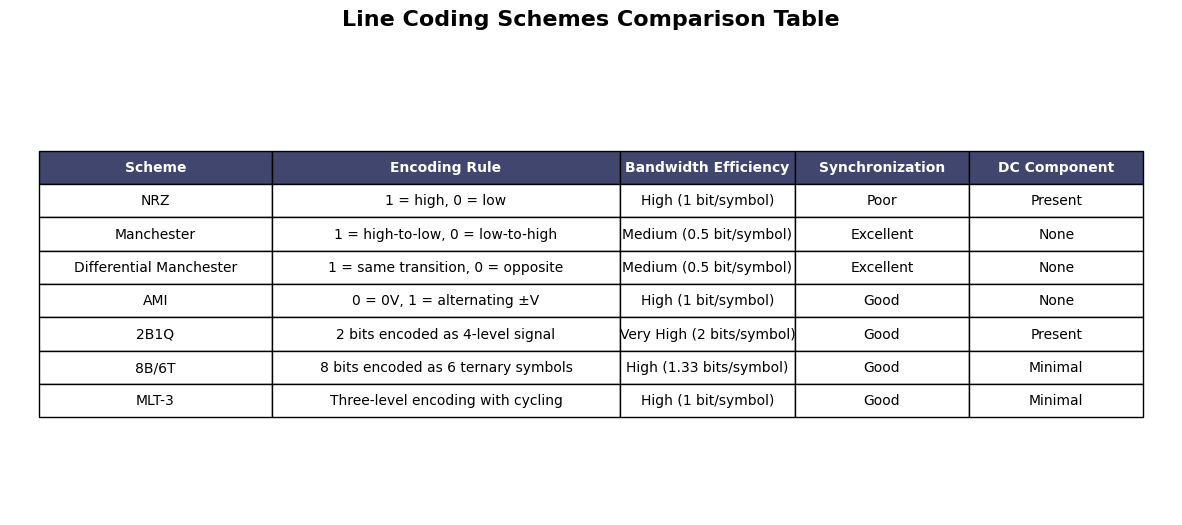


EXPLANATION OF EACH SCHEME:

NRZ (Non-Return-to-Zero):
  Simple encoding where 1 is represented by high voltage and 0 by low voltage. Easy to implement but lacks synchronization and has DC component.

Manchester:
  Each bit has a transition in the middle: 1 is high-to-low, 0 is low-to-high. Provides excellent synchronization and no DC component.

Differential Manchester:
  Similar to Manchester but uses transitions relative to previous bit. 1 means same transition as previous, 0 means opposite.

AMI (Alternate Mark Inversion):
  Three-level encoding where 0 is zero voltage and 1 alternates between +V and -V. No DC component and good error detection.

2B1Q (2 Binary 1 Quaternary):
  Groups 2 bits into one of four voltage levels. High bandwidth efficiency but susceptible to noise.

8B/6T:
  Groups 8 bits into 6 ternary symbols. Used in 100BASE-T4 Ethernet. Good balance of efficiency and DC balance.

MLT-3 (Multi-Level Transmit - 3 levels):
  Three-level encoding that cycles through stat

In [ ]:
# @title Line Coding Schemes Visualization
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Function to generate NRZ (Non-Return-to-Zero) encoding
def nrz_encode(bits):
    signal = []
    for bit in bits:
        signal.append(1 if bit == 1 else -1)
    return signal

# Function to generate Manchester encoding
def manchester_encode(bits):
    signal = []
    for bit in bits:
        if bit == 1:
            signal.extend([1, -1])  # 1: high-to-low
        else:
            signal.extend([-1, 1])  # 0: low-to-high
    return signal

# Function to generate Differential Manchester encoding
def diff_manchester_encode(bits, initial_state=1):
    signal = []
    last_bit = initial_state

    for bit in bits:
        if bit == 1:
            # Same transition as previous
            signal.extend([last_bit, -last_bit])
        else:
            # Opposite transition from previous
            last_bit = -last_bit
            signal.extend([last_bit, -last_bit])
    return signal

# Function to generate AMI (Alternate Mark Inversion) encoding
def ami_encode(bits):
    signal = []
    last_one = -1

    for bit in bits:
        if bit == 1:
            last_one = -last_one
            signal.append(last_one)
        else:
            signal.append(0)
    return signal

# Function to generate 2B1Q encoding
def two_b_one_q_encode(bits):
    # Group bits into pairs
    signal = []
    pairs = [bits[i:i+2] for i in range(0, len(bits), 2)]

    # Mapping for 2B1Q (simplified)
    mapping = {
        (0, 0): -3,
        (0, 1): -1,
        (1, 0): 1,
        (1, 1): 3
    }

    for pair in pairs:
        if len(pair) == 2:
            signal.append(mapping[tuple(pair)])
        else:
            signal.append(0)
    return signal

# Function to generate 8B/6T encoding (simplified)
def eight_b_six_t_encode(bits):
    # Simplified: map groups of 8 bits to 6 ternary symbols
    # This is a simplified version - actual 8B/6T has specific mapping tables
    signal = []
    groups = [bits[i:i+8] for i in range(0, len(bits), 8)]

    for group in groups:
        if len(group) == 8:
            # Simplified mapping: use pattern based on binary value
            val = sum([group[i] * (2**(7-i)) for i in range(8)])
            # Generate 6 ternary symbols based on val (simplified)
            for j in range(6):
                if j < 3:
                    signal.append(1 if (val >> (5-j)) & 1 else -1)
                else:
                    signal.append(-1 if (val >> (8-j)) & 1 else 1)
        else:
            signal.extend([0] * 6)
    return signal

# Function to generate MLT-3 encoding
def mlt3_encode(bits):
    signal = []
    state = 0  # 0, 1, 0, -1 cycling
    direction = 1

    for bit in bits:
        if bit == 1:
            if state == 0:
                state = direction
            elif state == direction:
                state = 0
                direction = -direction
            elif state == -direction:
                state = 0
            signal.append(state)
        else:
            signal.append(state)
    return signal

# Function to plot the encoding schemes
def plot_encoding_schemes(bits):
    # Create encodings
    encodings = {
        'NRZ': nrz_encode(bits),
        'Manchester': manchester_encode(bits),
        'Differential Manchester': diff_manchester_encode(bits),
        'AMI': ami_encode(bits),
        '2B1Q': two_b_one_q_encode(bits),
        '8B/6T (simplified)': eight_b_six_t_encode(bits),
        'MLT-3': mlt3_encode(bits)
    }

    # Create subplots
    fig, axes = plt.subplots(len(encodings), 1, figsize=(15, 12))
    fig.suptitle('Line Coding Schemes Comparison', fontsize=16, fontweight='bold')

    colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'cyan']

    for idx, (scheme_name, signal) in enumerate(encodings.items()):
        ax = axes[idx]
        time = np.arange(len(signal))

        # Plot the signal
        ax.step(time, signal, where='post', color=colors[idx], linewidth=2)
        ax.set_ylabel('Voltage')
        ax.set_title(scheme_name, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-3.5, 3.5)

        # Add bit markers
        if scheme_name in ['NRZ', 'AMI', 'MLT-3']:
            for i, bit in enumerate(bits):
                ax.text(i + 0.5, 3, str(bit), ha='center', va='center', fontsize=10, fontweight='bold')
        elif scheme_name in ['Manchester', 'Differential Manchester']:
            for i, bit in enumerate(bits):
                ax.text(i*2 + 1, 3, str(bit), ha='center', va='center', fontsize=10, fontweight='bold')
        elif scheme_name == '2B1Q':
            for i in range(0, len(bits), 2):
                if i+1 < len(bits):
                    ax.text(i/2 + 0.5, 3, f'{bits[i]}{bits[i+1]}', ha='center', va='center', fontsize=10, fontweight='bold')

        # Add horizontal line at 0
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

        # Set x-axis limits
        if scheme_name in ['Manchester', 'Differential Manchester']:
            ax.set_xlim(-0.5, len(bits)*2 - 0.5)
            ax.set_xticks(np.arange(0, len(bits)*2, 2))
            ax.set_xticklabels(bits)
        elif scheme_name == '2B1Q':
            ax.set_xlim(-0.5, len(bits)/2 - 0.5)
            ax.set_xticks(np.arange(len(bits)//2))
            ax.set_xticklabels([f'{bits[i]}{bits[i+1]}' for i in range(0, len(bits), 2)])
        else:
            ax.set_xlim(-0.5, len(bits) - 0.5)
            ax.set_xticks(np.arange(len(bits)))
            ax.set_xticklabels(bits)

    axes[-1].set_xlabel('Bit Index / Symbol Index', fontsize=12)
    plt.tight_layout()
    plt.show()

# Function to create comparison table
def create_comparison_table():
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.axis('tight')
    ax.axis('off')

    table_data = [
        ['Scheme', 'Encoding Rule', 'Bandwidth Efficiency', 'Synchronization', 'DC Component'],
        ['NRZ', '1 = high, 0 = low', 'High (1 bit/symbol)', 'Poor', 'Present'],
        ['Manchester', '1 = high-to-low, 0 = low-to-high', 'Medium (0.5 bit/symbol)', 'Excellent', 'None'],
        ['Differential Manchester', '1 = same transition, 0 = opposite', 'Medium (0.5 bit/symbol)', 'Excellent', 'None'],
        ['AMI', '0 = 0V, 1 = alternating ±V', 'High (1 bit/symbol)', 'Good', 'None'],
        ['2B1Q', '2 bits encoded as 4-level signal', 'Very High (2 bits/symbol)', 'Good', 'Present'],
        ['8B/6T', '8 bits encoded as 6 ternary symbols', 'High (1.33 bits/symbol)', 'Good', 'Minimal'],
        ['MLT-3', 'Three-level encoding with cycling', 'High (1 bit/symbol)', 'Good', 'Minimal']
    ]

    table = ax.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.2, 0.3, 0.15, 0.15, 0.15])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Style the header
    for i in range(5):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')

    plt.title('Line Coding Schemes Comparison Table', fontsize=16, fontweight='bold', pad=20)
    plt.show()

# Main execution
print("=" * 60)
print("LINE CODING SCHEMES VISUALIZATION")
print("=" * 60)

# Input bits
print("\nEnter a binary sequence (default: 1 0 1 1 0 0 1 0):")
user_input = input("Binary bits (space-separated): ").strip()

if user_input:
    try:
        bits = [int(b) for b in user_input.split()]
        if all(b in [0, 1] for b in bits):
            print(f"\nUsing bits: {bits}")
        else:
            print("Invalid input. Using default bits.")
            bits = [1, 0, 1, 1, 0, 0, 1, 0]
    except:
        print("Invalid input. Using default bits.")
        bits = [1, 0, 1, 1, 0, 0, 1, 0]
else:
    bits = [1, 0, 1, 1, 0, 0, 1, 0]
    print(f"Using default bits: {bits}")

# Plot the encodings
plot_encoding_schemes(bits)

# Show comparison table
create_comparison_table()

# Additional explanations
print("\n" + "=" * 60)
print("EXPLANATION OF EACH SCHEME:")
print("=" * 60)

explanations = {
    "NRZ (Non-Return-to-Zero)": "Simple encoding where 1 is represented by high voltage and 0 by low voltage. Easy to implement but lacks synchronization and has DC component.",

    "Manchester": "Each bit has a transition in the middle: 1 is high-to-low, 0 is low-to-high. Provides excellent synchronization and no DC component.",

    "Differential Manchester": "Similar to Manchester but uses transitions relative to previous bit. 1 means same transition as previous, 0 means opposite.",

    "AMI (Alternate Mark Inversion)": "Three-level encoding where 0 is zero voltage and 1 alternates between +V and -V. No DC component and good error detection.",

    "2B1Q (2 Binary 1 Quaternary)": "Groups 2 bits into one of four voltage levels. High bandwidth efficiency but susceptible to noise.",

    "8B/6T": "Groups 8 bits into 6 ternary symbols. Used in 100BASE-T4 Ethernet. Good balance of efficiency and DC balance.",

    "MLT-3 (Multi-Level Transmit - 3 levels)": "Three-level encoding that cycles through states: 0, +V, 0, -V. Used in Fast Ethernet for better EMI characteristics."
}

for scheme, explanation in explanations.items():
    print(f"\n{scheme}:")
    print(f"  {explanation}")

print("\n" + "=" * 60)
print("KEY OBSERVATIONS:")
print("=" * 60)
print("• NRZ is simplest but has synchronization issues")
print("• Manchester encoding provides self-clocking but doubles bandwidth")
print("• AMI eliminates DC component and provides error detection")
print("• 2B1Q achieves highest bandwidth efficiency")
print("• MLT-3 reduces EMI for high-speed transmission")
print("• 8B/6T provides good DC balance for Ethernet applications")
print("• Differential encoding is immune to polarity inversion")

### Per cell

In [1]:
# 📡 Line Codes Visualization

This notebook graphically displays 7 line coding schemes used in digital communications:

| Code | Full Name | Levels |
|------|-----------|--------|
| **NRZ** | Non-Return-to-Zero Level | 2 |
| **Manchester** | IEEE 802.3 Manchester | 2 |
| **Differential Manchester** | Transition-based Manchester | 2 |
| **AMI** | Alternate Mark Inversion | 3 |
| **2B1Q** | 2 Binary, 1 Quaternary | 4 |
| **8B/6T** | 8 Binary, 6 Ternary | 3 |
| **MLT-3** | Multi-Level Transmit – 3 levels | 3 |

### How to use
1. **Cell 2** — Toggle codes on/off and set the input bits
2. **Cell 3** — Imports and plot style
3. **Cells 4–10** — One encoder per line code
4. **Cell 11** — Run to generate the plot

SyntaxError: invalid decimal literal (689070606.py, line 11)

In [2]:
# ================================================================
#  CONFIGURATION
#  Set True / False to include or exclude each line code.
#  Change BITS to any sequence of 0s and 1s (≥ 8 if 8B/6T is on).
# ================================================================

SHOW = {
    'NRZ':                     True,
    'Manchester':               True,
    'Differential Manchester':  True,
    'AMI':                     True,
    '2B1Q':                    True,
    '8B/6T':                   True,
    'MLT-3':                   True,
}

BITS = [1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1]

# ── Validation ──────────────────────────────────────────────────
if SHOW.get('8B/6T') and len(BITS) < 8:
    raise ValueError('8B/6T requires at least 8 input bits.')

active = [k for k, v in SHOW.items() if v]
print(f'Active codes : {active}')
print(f'Input bits   : {BITS}  ({len(BITS)} bits)')

Active codes : ['NRZ', 'Manchester', 'Differential Manchester', 'AMI', '2B1Q', '8B/6T', 'MLT-3']
Input bits   : [1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1]  (12 bits)


In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# White background everywhere
matplotlib.rcParams['figure.facecolor']  = 'white'
matplotlib.rcParams['axes.facecolor']    = 'white'
matplotlib.rcParams['savefig.facecolor'] = 'white'

# Colour palette — one colour per line code
COLORS = {
    'NRZ':                     '#1f77b4',  # blue
    'Manchester':               '#d62728',  # red
    'Differential Manchester':  '#2ca02c',  # green
    'AMI':                     '#9467bd',  # purple
    '2B1Q':                    '#ff7f0e',  # orange
    '8B/6T':                   '#8c564b',  # brown
    'MLT-3':                   '#e377c2',  # pink
}

def staircase(times, levels):
    """
    Convert parallel time/level arrays into an (x, y) step-waveform
    suitable for plt.step() or plain plt.plot().
    Each level is held constant until the next time point.
    """
    x, y = [], []
    for i, (t, lev) in enumerate(zip(times, levels)):
        x.append(t)
        y.append(lev)
        if i + 1 < len(times):
            x.append(times[i + 1])
            y.append(lev)
    return np.array(x), np.array(y)

print('Imports and helpers ready.')

Imports and helpers ready.


In [4]:
def encode_NRZ(bits):
    """
    NRZ-L (Non-Return-to-Zero Level)
    ──────────────────────────────────
    Rule : 1 → +1 V  |  0 → -1 V
    Level stays constant for the entire bit period — no mid-bit transitions.
    Simple but has a DC component and no self-clocking.
    """
    levels = [1 if b else -1 for b in bits]
    x, y   = staircase(list(range(len(bits))), levels)
    # extend the last level to the end of the final bit period
    return np.append(x, len(bits)), np.append(y, y[-1])

# Quick preview
x, y = encode_NRZ(BITS)
print(f'NRZ  — {len(BITS)} bits → {len(levels := [1 if b else -1 for b in BITS])} levels: {levels}')

NRZ  — 12 bits → 12 levels: [1, -1, 1, 1, -1, -1, 1, -1, 1, 1, -1, 1]


In [5]:
def encode_Manchester(bits):
    """
    Manchester (IEEE 802.3)
    ────────────────────────
    Rule : 1 → HIGH first half, then LOW  (↓ transition at mid-bit)
           0 → LOW  first half, then HIGH (↑ transition at mid-bit)
    Always has a transition at the centre of each bit → self-clocking.
    Doubles the required bandwidth compared to NRZ.
    """
    x, y = [], []
    for i, b in enumerate(bits):
        hi, lo = (1, -1) if b else (-1, 1)
        for pt in [(i, hi), (i+.5, hi), (i+.5, lo), (i+1, lo)]:
            # Avoid duplicate x-points unless the level actually changes
            if x and x[-1] == pt[0] and y[-1] != pt[1]:
                x.append(pt[0]); y.append(pt[1])
            elif not x or x[-1] != pt[0]:
                x.append(pt[0]); y.append(pt[1])
    return np.array(x), np.array(y)

print('Manchester encoder defined.')

Manchester encoder defined.


In [6]:
def encode_DiffManchester(bits):
    """
    Differential Manchester
    ────────────────────────
    Rule : There is ALWAYS a transition at the MID-POINT of every bit.
           Additionally:
             0 → extra transition at the START of the bit
             1 → no transition at the start
    Polarity is relative, so signal sense can be inverted without error.
    Used in Token Ring (IEEE 802.5).
    """
    x, y  = [0], [1]
    cur   = 1                       # current signal level

    for i, b in enumerate(bits):
        if b == 0:
            cur = -cur              # transition at bit start for '0'
        # first half of bit
        x += [i,      i + .5]
        y += [cur,    cur   ]
        # mid-bit transition (always)
        cur = -cur
        x += [i + .5]
        y += [cur    ]

    x.append(len(bits))
    y.append(cur)
    return np.array(x), np.array(y)

print('Differential Manchester encoder defined.')

Differential Manchester encoder defined.


In [7]:
def encode_AMI(bits):
    """
    AMI — Alternate Mark Inversion
    ────────────────────────────────
    Rule : 0 → 0 V  (zero voltage, no pulse)
           1 → alternates between +1 V and -1 V with each occurrence
    Three voltage levels: -1, 0, +1.
    DC-balanced (no DC component). Long strings of 0s lose clock sync.
    Used in T1/E1 trunk lines.
    """
    polarity = 1
    levels   = []
    for b in bits:
        if b == 0:
            levels.append(0)
        else:
            levels.append(polarity)
            polarity = -polarity        # flip polarity for next mark

    x, y = staircase(list(range(len(bits))), levels)
    return np.append(x, len(bits)), np.append(y, y[-1])

print('AMI encoder defined.')

AMI encoder defined.


In [8]:
def encode_2B1Q(bits):
    """
    2B1Q — 2 Binary, 1 Quaternary
    ──────────────────────────────
    Each PAIR of bits maps to one of four voltage levels:
        00 → -3 V   |   01 → -1 V   |   11 → +1 V   |   10 → +3 V
    Doubles bit efficiency vs NRZ (2 bits per baud).
    Used in ISDN Basic Rate Interface (BRI).
    """
    MAP = {(0,0): -3, (0,1): -1, (1,1): 1, (1,0): 3}

    b = bits[:] + ([0] if len(bits) % 2 else [])    # pad to even length
    levels = [MAP[(b[i], b[i+1])] for i in range(0, len(b), 2)]

    x, y = staircase(list(range(len(levels))), levels)
    n_sym = len(levels)
    return np.append(x, n_sym), np.append(y, y[-1]), n_sym

_, _, ns = encode_2B1Q(BITS)
print(f'2B1Q — {len(BITS)} bits → {ns} quaternary symbols')

2B1Q — 12 bits → 6 quaternary symbols


In [9]:
def encode_8B6T(bits):
    """
    8B/6T — 8 Binary, 6 Ternary
    ─────────────────────────────
    Every group of 8 bits is encoded into 6 ternary symbols {-1, 0, +1}.
    3^6 = 729 possible codewords > 2^8 = 256 needed → DC-balance is achievable.
    Improves bandwidth efficiency and reduces DC wander.
    Used in 100BASE-T4 Ethernet.

    Note: A full 8B/6T standard uses a look-up table with 256 balanced codewords.
    This implementation uses a deterministic base-3 decomposition for illustration.
    """
    b = bits[:]
    while len(b) % 8:
        b.append(0)             # zero-pad to a multiple of 8

    def byte_to_6T(byte_bits):
        val  = int(''.join(str(x) for x in byte_bits), 2)   # 8-bit integer 0-255
        syms = []
        for _ in range(6):
            syms.append(val % 3 - 1)    # map {0,1,2} → {-1,0,+1}
            val //= 3
        return syms[::-1]               # MSB first

    levels = []
    for i in range(0, len(b), 8):
        levels.extend(byte_to_6T(b[i:i+8]))

    x, y  = staircase(list(range(len(levels))), levels)
    n_sym = len(levels)
    return np.append(x, n_sym), np.append(y, y[-1]), n_sym

_, _, ns = encode_8B6T(BITS)
print(f'8B/6T — {len(BITS)} bits (padded to {((len(BITS)+7)//8)*8}) → {ns} ternary symbols')

8B/6T — 12 bits (padded to 16) → 12 ternary symbols


In [10]:
def encode_MLT3(bits):
    """
    MLT-3 — Multi-Level Transmit, 3 levels
    ────────────────────────────────────────
    Three levels: -1, 0, +1.
    Rule : 0 → no change (hold current level)
           1 → advance one step in the repeating cycle: 0 → +1 → 0 → -1 → 0 → …
    Reduces high-frequency content compared to NRZ.
    Used in 100BASE-TX (Fast Ethernet over Cat-5).
    """
    cycle  = [0, 1, 0, -1]     # repeating voltage sequence
    state  = 0                  # index into cycle
    levels = []

    for b in bits:
        if b == 1:
            state = (state + 1) % 4     # advance cycle only on '1'
        levels.append(cycle[state])

    x, y = staircase(list(range(len(bits))), levels)
    return np.append(x, len(bits)), np.append(y, y[-1])

print('MLT-3 encoder defined.')

MLT-3 encoder defined.


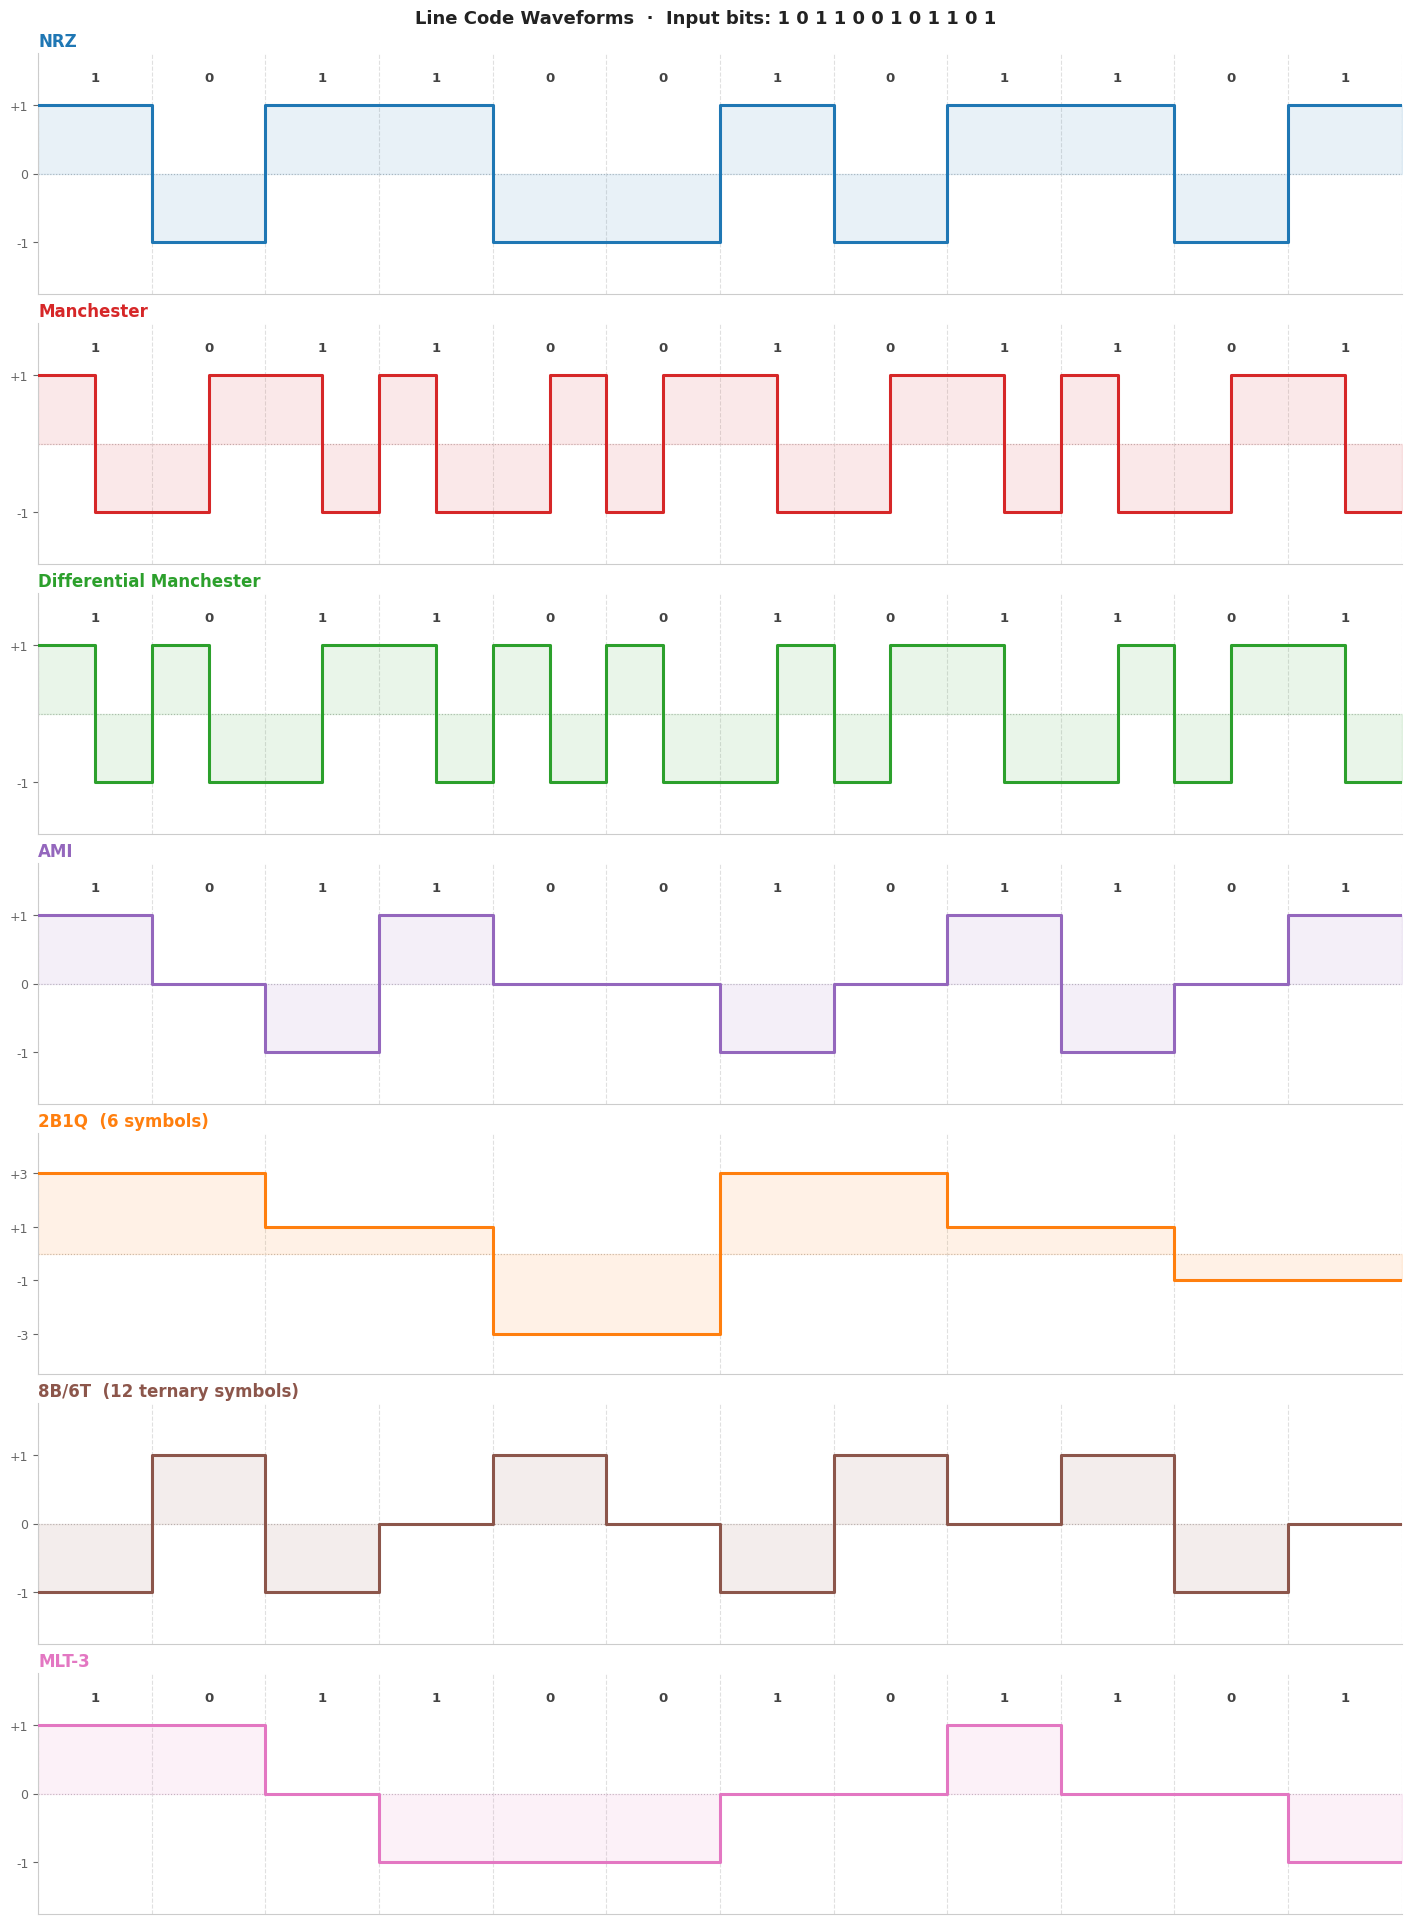

✅  Plotted 7 line code(s). Figure saved as line_codes.png


In [11]:
# ── Build list of active codes from configuration (Cell 2) ──────
active = [name for name, show in SHOW.items() if show]
n      = len(active)

if n == 0:
    print('⚠️  Nothing to plot. Set at least one code to True in Cell 2.')
else:
    # ── Figure layout ───────────────────────────────────────────
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.7 * n),
                             facecolor='white', constrained_layout=True)
    if n == 1:
        axes = [axes]   # keep iterable

    # ── Per-subplot metadata ─────────────────────────────────────
    META = {
        'NRZ':                     dict(yticks=[-1,0,1],   ylim=(-1.75,1.75), ylabels=['-1','0','+1']),
        'Manchester':               dict(yticks=[-1,1],     ylim=(-1.75,1.75), ylabels=['-1','+1']),
        'Differential Manchester':  dict(yticks=[-1,1],     ylim=(-1.75,1.75), ylabels=['-1','+1']),
        'AMI':                      dict(yticks=[-1,0,1],   ylim=(-1.75,1.75), ylabels=['-1','0','+1']),
        '2B1Q':                     dict(yticks=[-3,-1,1,3],ylim=(-4.5,4.5),   ylabels=['-3','-1','+1','+3']),
        '8B/6T':                    dict(yticks=[-1,0,1],   ylim=(-1.75,1.75), ylabels=['-1','0','+1']),
        'MLT-3':                    dict(yticks=[-1,0,1],   ylim=(-1.75,1.75), ylabels=['-1','0','+1']),
    }

    # ── Draw each subplot ────────────────────────────────────────
    for ax, name in zip(axes, active):
        color = COLORS[name]
        meta  = META[name]
        extra = ''

        # call the appropriate encoder
        if   name == 'NRZ':                     x, y        = encode_NRZ(BITS);           xlim = (0, len(BITS))
        elif name == 'Manchester':              x, y        = encode_Manchester(BITS);    xlim = (0, len(BITS))
        elif name == 'Differential Manchester': x, y        = encode_DiffManchester(BITS);xlim = (0, len(BITS))
        elif name == 'AMI':                     x, y        = encode_AMI(BITS);           xlim = (0, len(BITS))
        elif name == '2B1Q':                    x, y, n_sym = encode_2B1Q(BITS);          xlim = (0, n_sym); extra = f'  ({n_sym} symbols)'
        elif name == '8B/6T':                   x, y, n_sym = encode_8B6T(BITS);          xlim = (0, n_sym); extra = f'  ({n_sym} ternary symbols)'
        elif name == 'MLT-3':                   x, y        = encode_MLT3(BITS);          xlim = (0, len(BITS))

        yl = meta['ylim']

        # waveform + shading
        ax.step(x, y, where='post', color=color, linewidth=2.2, zorder=3)
        ax.fill_between(x, y, step='post', alpha=0.10, color=color, zorder=2)

        # zero reference
        ax.axhline(0, color='#c0c0c0', linewidth=0.8, linestyle=':', zorder=1)

        # bit/symbol boundary grid
        for i in range(int(xlim[1]) + 1):
            ax.axvline(i, color='#e0e0e0', linewidth=0.8, linestyle='--', zorder=1)

        # bit value labels above waveform (only for bit-domain codes)
        if name not in ('2B1Q', '8B/6T'):
            for i, b in enumerate(BITS):
                ax.text(i + 0.5, yl[1] * 0.80, str(b),
                        ha='center', va='center',
                        fontsize=9.5, color='#444444', fontweight='bold')

        # axes formatting
        ax.set_xlim(xlim)
        ax.set_ylim(yl)
        ax.set_yticks(meta['yticks'])
        ax.set_yticklabels(meta['ylabels'], fontsize=9)
        ax.set_xticks([])
        ax.set_title(f'{name}{extra}', fontsize=12,
                     fontweight='bold', color=color, loc='left', pad=5)
        ax.set_facecolor('white')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_color('#cccccc')
        ax.spines['left'].set_color('#cccccc')
        ax.tick_params(colors='#666666')

    # ── Super-title ──────────────────────────────────────────────
    fig.suptitle('Line Code Waveforms  ·  Input bits: ' + ' '.join(str(b) for b in BITS),
                 fontsize=13, fontweight='bold', color='#222222', y=1.01)

    plt.savefig('line_codes.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'✅  Plotted {n} line code(s). Figure saved as line_codes.png')